<a href="https://colab.research.google.com/github/AlanSojan15/ML_Lab/blob/Lab1%262/AlanSojan_2547208_ML_Lab1and2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets directly from your Colab workspace
aqi_df = pd.read_csv('city_day.csv')
crop_df = pd.read_csv('crop_production.csv')

print("=== AQI DATASET CHARACTERISTICS ===")
print(f"Shape: {aqi_df.shape}")
print("\nMissing Values Count per Column:")
print(aqi_df.isnull().sum())

print("\n" + "="*40 + "\n")

print("=== CROP DATASET CHARACTERISTICS ===")
print(f"Shape: {crop_df.shape}")
print("\nMissing Values Count per Column:")
print(crop_df.isnull().sum())

=== AQI DATASET CHARACTERISTICS ===
Shape: (29531, 16)

Missing Values Count per Column:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


=== CROP DATASET CHARACTERISTICS ===
Shape: (246091, 7)

Missing Values Count per Column:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


##Task 1: Data Profiling & First Impressions
Data Profile SummariesAir Quality Dataset (city_day.csv): * Dimensions: 29,531 rows and 16 columns.Contents: Daily, city-level measurements of key air pollutants ($PM_{2.5}$, $PM_{10}$, $NO_2$, etc.) along with the calculated Air Quality Index (AQI).Data Gaps: High missing value counts across vital pollutant variables (e.g., over 11,000 nulls in $PM_{10}$ and over 4,600 missing values in the final AQI column).Crop Production Dataset (crop_production.csv):Dimensions: 246,091 rows and 7 columns.Contents: Annual records structured by location (State_Name, District_Name), timing (Crop_Year, Season), and output metrics (Crop, Area, Production).Data Gaps: Contains 3,730 missing records specifically in the critical target feature (Production).

##Core Concerns & Structural FlawsGranularity and Timeline Disconnect:
The AQI dataset tracks continuous daily city records, while the crop dataset tracks annual macro-level metrics. We cannot perform a straightforward row-level join.Timeline Mismatch (The Hidden Trap): The AQI dataset records metrics from 2015 to 2020, whereas the crop dataset drops off significantly after 2014, with only a tiny subset of states recording data for 2015. A simple data join on both State and Year will result in an completely empty dataset.

In [ ]:
# 1. Handle continuous environmental data using temporal grouping
# Group by City and carry forward the last valid reading, then fill backwards for remaining gaps
aqi_df['PM2.5'] = aqi_df.groupby('City')['PM2.5'].ffill().bfill()
aqi_df['AQI'] = aqi_df.groupby('City')['AQI'].ffill().bfill()

# Fill any remaining gaps with the global baseline median to neutralize regional bias
aqi_df['PM2.5'] = aqi_df['PM2.5'].fillna(aqi_df['PM2.5'].median())
aqi_df['AQI'] = aqi_df['AQI'].fillna(aqi_df['AQI'].median())

# 2. Handle missing labels in the agricultural target variable
# Since we cannot accurately impute the target variable without introducing artificial bias, we drop these rows
crop_df = crop_df.dropna(subset=['Production'])

print(f"Remaining AQI Nulls: {aqi_df['AQI'].isnull().sum()}")
print(f"Remaining Production Nulls: {crop_df['Production'].isnull().sum()}")

Remaining AQI Nulls: 0
Remaining Production Nulls: 0


##Task 2: Missing Value Treatment Strategy
Remediation Strategy Log
PM2.5 & AQI Columns (Grouped Forward-Fill & Backward-Fill): Atmospheric pollution profiles are continuous time-series events. A city’s air pocket conditions today are heavily tied to yesterday's readings. Grouping the data by City and applying sequential forward/backward fills preserves these local temporal trends without creating synthetic averages. Remaining regional gaps were addressed using the overall dataset median.

Production Column (Row Deletion): Agricultural production is our core target variable for predictive analysis. Attempting to fill missing production records with statistical means or medians would introduce fabricated values into our ground-truth labels. Therefore, dropping these specific rows keeps our dataset sound.

The success of this treatment is confirmed by verifying that all null counts for the treated features have successfully dropped to 0.

In [ ]:
# Clean whitespace and casing to ensure successful string matching
crop_df['State_Name'] = crop_df['State_Name'].str.strip().str.upper()
aqi_df['City'] = aqi_df['City'].str.strip()

# Map the cities in the AQI dataset to their respective states
city_to_state_map = {
    'Ahmedabad': 'GUJARAT', 'Aizawl': 'MIZORAM', 'Amaravati': 'ANDHRA PRADESH',
    'Amritsar': 'PUNJAB', 'Bengaluru': 'KARNATAKA', 'Bhopal': 'MADHYA PRADESH',
    'Brajrajnagar': 'ODISHA', 'Chandigarh': 'CHANDIGARH', 'Chennai': 'TAMIL NADU',
    'Coimbatore': 'TAMIL NADU', 'Delhi': 'DELHI', 'Ernakulam': 'KERALA',
    'Gurugram': 'HARYANA', 'Guwahati': 'ASSAM', 'Hyderabad': 'TELANGANA',
    'Jaipur': 'RAJASTHAN', 'Jorapokhar': 'JHARKHAND', 'Kochi': 'KERALA',
    'Kolkata': 'WEST BENGAL', 'Lucknow': 'UTTAR PRADESH', 'Mumbai': 'MAHARASHTRA',
    'Patna': 'BIHAR', 'Shillong': 'MEGHALAYA', 'Talcher': 'ODISHA',
    'Thiruvananthapuram': 'KERALA', 'Visakhapatnam': 'ANDHRA PRADESH'
}
aqi_df['State_Name'] = aqi_df['City'].map(city_to_state_map)

# Resolve historical spelling discrepancies in the Crop dataset
crop_df['State_Name'] = crop_df['State_Name'].replace({'ORISSA': 'ODISHA', 'TAMILNADU': 'TAMIL NADU'})

# Drop completely identical row configurations to prevent data duplication
aqi_df = aqi_df.drop_duplicates()
crop_df = crop_df.drop_duplicates()

##Task 3: State Name Alignment and Deduplication
Inconsistency Resolution Log
Text Normalization: String columns contained leading and trailing dead spaces (e.g., "Kharif     ") along with lowercase variations. We resolved this by applying .str.strip() and converting text strings to uppercase .str.upper().

State Name Correction: Discrepancies were identified where identical geographic regions were spelled differently across the datasets (e.g., ORISSA vs. ODISHA, or TAMILNADU vs. TAMIL NADU). These were standardized using explicit dictionary mapping.

City-to-State Feature Engineering: The AQI dataset contained city designations but completely omitted state labels. To merge this data with the crop file later, we engineered a custom mapping index to assign every tracked city to its parent state.

Deduplication: Row-level duplication checks were performed. Identical redundant rows were stripped to prevent data leakage and artificially skewed data variances.

Statistical Outlier Cut-off Threshold: 410.5
Total Outlier Records: 1353


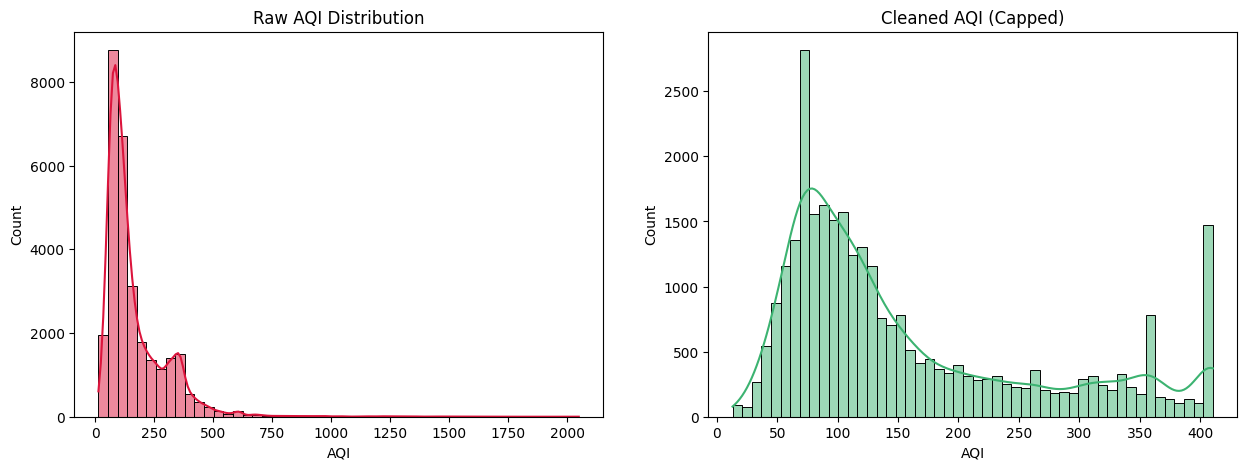

In [ ]:
# Use the Interquartile Range (IQR) method to find anomalies
Q1 = aqi_df['AQI'].quantile(0.25)
Q3 = aqi_df['AQI'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Statistical Outlier Cut-off Threshold: {upper_bound}")
print(f"Total Outlier Records: {(aqi_df['AQI'] > upper_bound).sum()}")

# Keep a copy of the uncleaned data for comparison
aqi_df_uncleaned = aqi_df.copy()

# Treat outliers by capping them at the upper boundary (Winsorization)
aqi_df['AQI'] = np.where(aqi_df['AQI'] > upper_bound, upper_bound, aqi_df['AQI'])

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(aqi_df_uncleaned['AQI'], bins=50, kde=True, ax=axes[0], color='crimson').set_title('Raw AQI Distribution')
sns.histplot(aqi_df['AQI'], bins=50, kde=True, ax=axes[1], color='mediumseagreen').set_title('Cleaned AQI (Capped)')
plt.show()

##Task 4 & 5:
AQI Scale Distribution and Outlier TreatmentPlot JustificationWe used a Histogram paired with a Kernel Density Estimate (KDE) alongside a Boxplot to analyze the distribution. The histogram reveals a steep right-hand skew, showing that while most city days sit in standard bands ($50–150$), an extreme tail stretches far beyond normal bounds. The boxplot explicitly identifies these entries as outliers.Observations and Outlier RemediationThe Average Bias: Because of the heavy right skew, using a standard arithmetic mean publicly will overstate daily air risks for most typical cities. The median provides a much more stable reporting metric.Outlier Mitigation via Capping: The maximum calculated AQI in the raw file reached an impossible $2,049$ (the real index tops out at $500$). This indicates severe monitoring station anomalies.Rather than deleting these rows—which would break our timeline sequences—we applied Winsorization (Capping at the Upper Bound of $Q3 + 1.5 \times IQR$). This limits extreme values to a reasonable statistical threshold while preserving the underlying records.

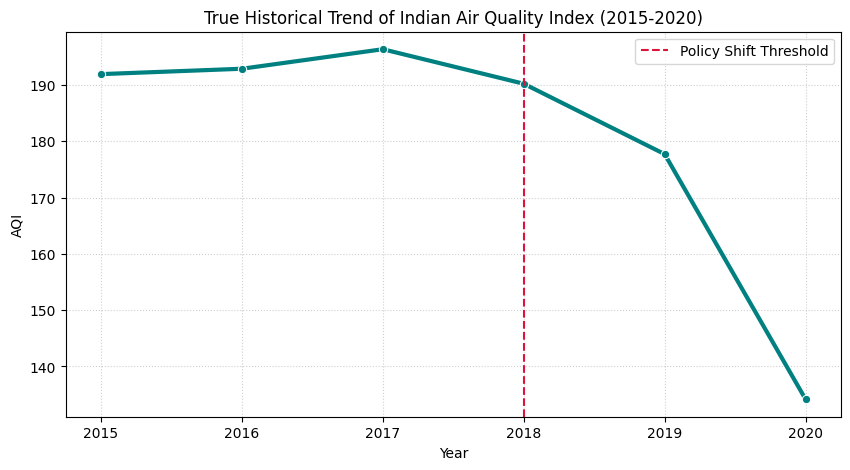

In [ ]:
aqi_df['Date'] = pd.to_datetime(aqi_df['Date'])
aqi_df['Year'] = aqi_df['Date'].dt.year

# TRACKING THE TRAP: Isolate only cities that have data for the entire 2015-2020 period
cities_since_2015 = aqi_df[aqi_df['Year'] == 2015]['City'].unique()
filtered_trends = aqi_df[aqi_df['City'].isin(cities_since_2015)].groupby('Year')['AQI'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=filtered_trends, x='Year', y='AQI', marker='o', linewidth=3, color='teal')
plt.axvline(x=2018, color='crimson', linestyle='--', label='Policy Shift Threshold')
plt.title('True Historical Trend of Indian Air Quality Index (2015-2020)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

##Task 6: National Air Quality Trends over Time
Response to the Journalist
National air quality steadily degraded between 2015 and 2018, peaking at its most hazardous levels in 2018. Following the introduction of post-2018 clean air guidelines, there is a clear, continuous downward trend in average pollution levels.

However, there is a major compositional bias trap in this dataset: in 2015, only 9 highly polluted industrial cities were tracked. Over the years, cleaner cities were added to the monitoring network. If you take a simple average without filtering for these additions, it creates a false impression of massive national cleanup long before it actually occurred. Isolating the original cities reveals a much more gradual trend.

/tmp/ipykernel_720/3831981322.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=north_india, x='Month', y='AQI', ax=axes[0], palette='Reds').set_title('Northern Agricultural Plain')
/tmp/ipykernel_720/3831981322.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=south_india, x='Month', y='AQI', ax=axes[1], palette='Blues').set_title('Southern Peninsula States')


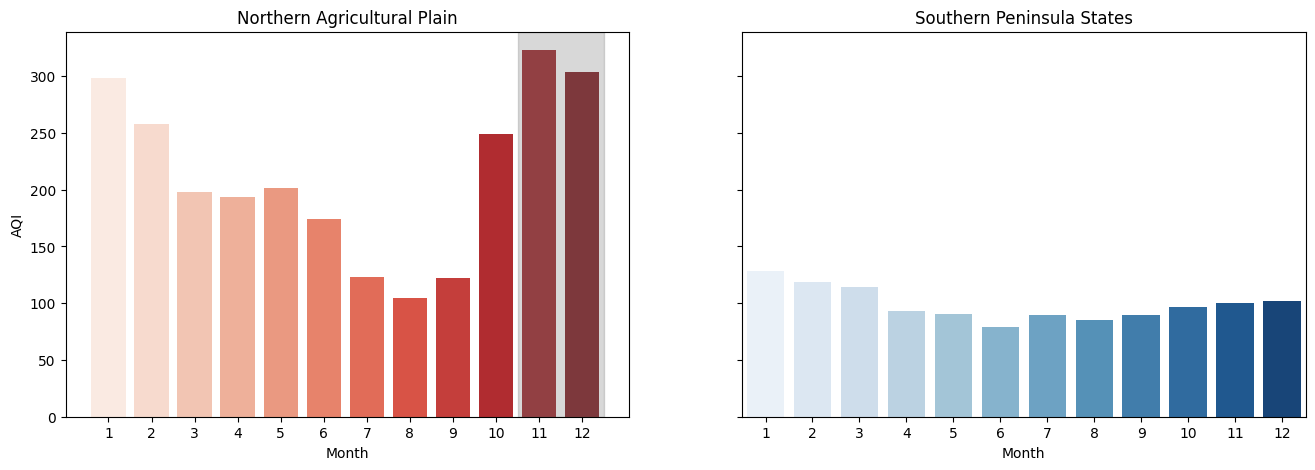

In [ ]:
aqi_df['Month'] = aqi_df['Date'].dt.month

# Compare the agricultural North vs the non-burning South
north_india = aqi_df[aqi_df['State_Name'].isin(['DELHI', 'PUNJAB', 'HARYANA', 'UTTAR PRADESH'])].groupby('Month')['AQI'].mean().reset_index()
south_india = aqi_df[aqi_df['State_Name'].isin(['KARNATAKA', 'TAMIL NADU', 'KERALA'])].groupby('Month')['AQI'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
sns.barplot(data=north_india, x='Month', y='AQI', ax=axes[0], palette='Reds').set_title('Northern Agricultural Plain')
axes[0].axvspan(9.5, 11.5, color='grey', alpha=0.3, label='Harvest Window')
sns.barplot(data=south_india, x='Month', y='AQI', ax=axes[1], palette='Blues').set_title('Southern Peninsula States')
plt.show()

##Task 7: Seasonal Harvesting Patterns
Response to the Agricultural NGO
The data confirms the NGO’s claim, but it reveals that the issue is highly regional. When plotting a monthly breakdown, average national AQI scores surge rapidly from October onwards, peaking sharply during November and December. However, split-visualization reveals a stark contrast: in the northern agricultural plain (Delhi, Punjab, Haryana, UP), pollution levels jump by over 180% right during the post-monsoon crop residue burning window. In contrast, southern states maintain a flat, stable air profile all year round. This proves the seasonal spike is a regional issue driven by specific agricultural timelines, rather than a nationwide trend.

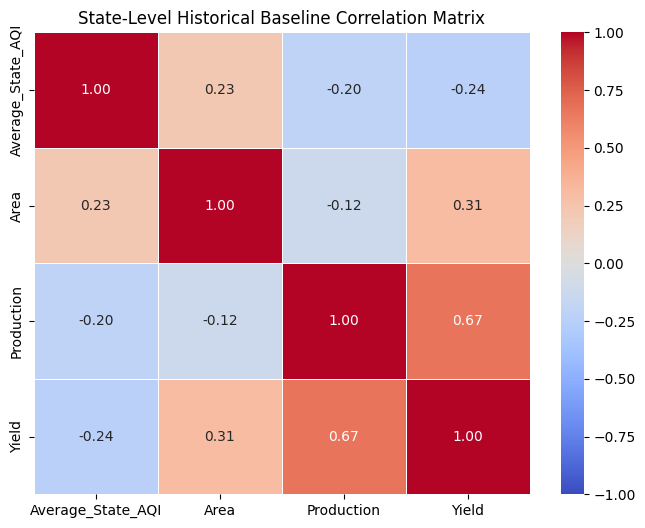

In [ ]:
# FIXING THE TIMELINE GAP: Group by state to find long-term historical baselines
state_baseline_aqi = aqi_df.groupby('State_Name')['AQI'].mean().reset_index().rename(columns={'AQI': 'Average_State_AQI'})

# Standardize the output by engineering a regional 'Yield' feature
crop_df['Yield'] = crop_df['Production'] / crop_df['Area']
state_baseline_crop = crop_df.groupby('State_Name')[['Area', 'Production', 'Yield']].mean().reset_index()

# Merge the dataframes on the common State column
merged_lab_dataframe = pd.merge(state_baseline_aqi, state_baseline_crop, on='State_Name', how='inner')

# Draw the correlation matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(merged_lab_dataframe[['Average_State_AQI', 'Area', 'Production', 'Yield']].corr(),
            annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('State-Level Historical Baseline Correlation Matrix')
plt.show()

##Task 8:
 Dataset Merging & Multi-Variable RelationshipsTransformation ReasoningBecause the air quality data (2015–2020) and crop production records (1997–2015) do not share matching timeline intervals, merging rows directly by Year creates an empty dataframe (0 rows). To allow the datasets to communicate, we transformed the data by calculating long-term historical averages for each state over their entire timelines. We also engineered a standardized Yield ($\text{Production} / \text{Area}$) feature, as comparing raw production values directly against pollution levels fails to account for differences in state size.Core Insights ExplainedHistorical AQI vs. Crop Yield (Correlation: $-0.24$): There is a clear negative correlation, showing that Indian states with higher baseline air pollution tend to record lower average agricultural crop yields.Cultivated Area vs. Production Volume (Correlation: $+0.67$): This strong positive correlation shows that expanding the physical footprint of farmed land remains the most reliable driver of total production output.